# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [19]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score, ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** "can we predict whether an employee will stay with a company or leave using workplace and demographic characteristics to help HR maintain retention?"

**This is a prediction (umbrella) problem because:** "the goal of this project is not to determine concretely whether a single factor causes employees to leave, rather it is simply predicting the likelihood of attrition using a range of observable features."

**The decision this enables:** "the stakeholders would be HR managers, who can use the insights derived from this analysis to help better identify high-risk employees and better structure retention strategies / programs to improve workplace morale and efficiency."

**Dataset:** "IBM HR Analytics Employee Attrition & Performance" 
- **Source:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
- **N =** 1470
- **Features =** 34
- **Target variable =** "Attrition" (yes/no variable)
- **Access date:** 4/21/2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [20]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

# df = pd.read_csv('https://example.com/data.csv')

# Uncomment and modify one of the lines above
df = pd.read_csv('ibm_hr_dataset.csv')

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 2.2 Basic Description

In [21]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


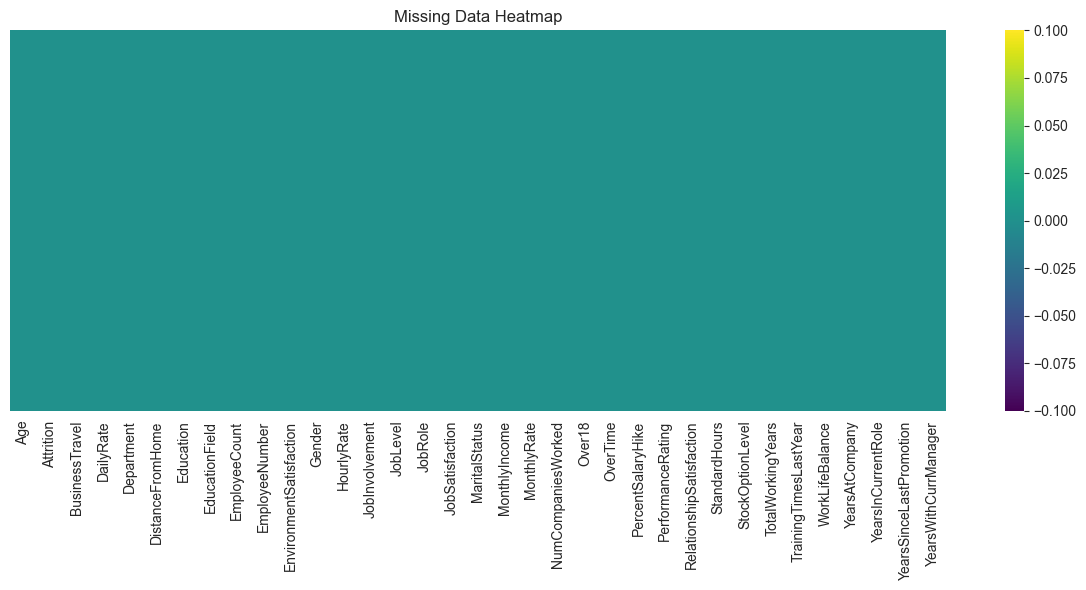

In [22]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** ___ 
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)

### 2.4 Distribution Plots

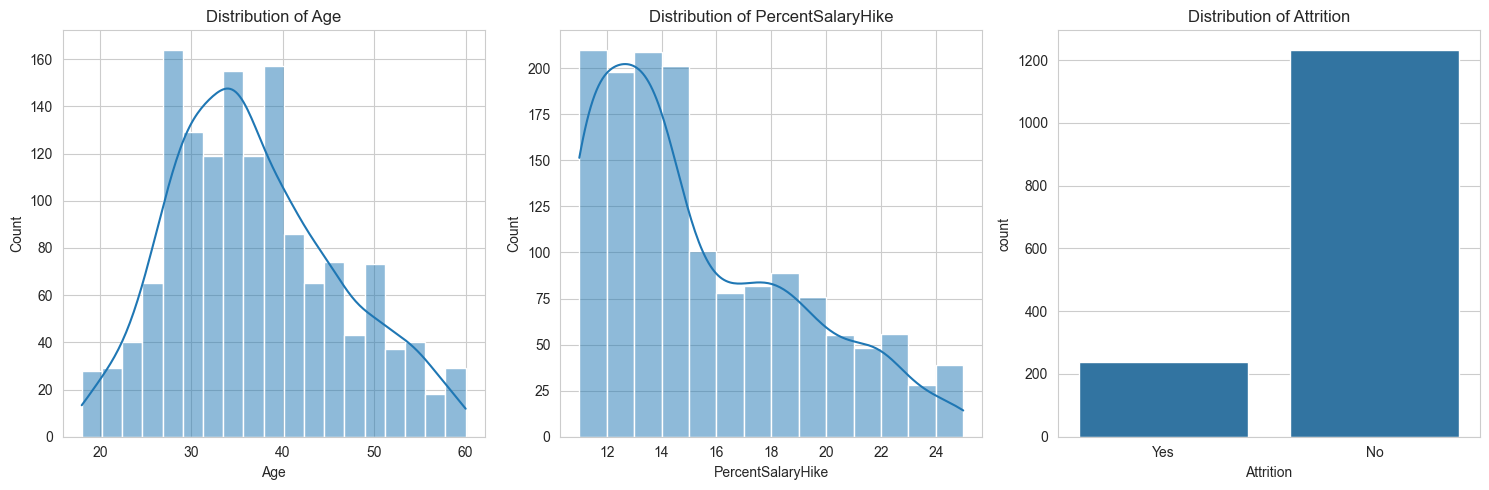

In [23]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# 
sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')

# 
sns.histplot(df['PercentSalaryHike'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of PercentSalaryHike')
# 
sns.countplot(x='Attrition', data=df, ax=axes[2])
axes[2].set_title('Distribution of Attrition')

# 
plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [24]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
     """Return lower and upper Tukey fences."""
     Q1 = series.quantile(0.25)
     Q3 = series.quantile(0.75)
     IQR = Q3 - Q1
     return Q1 - k * IQR, Q3 + k * IQR
 
# # Example: check outliers in a numeric column
col1 = 'MonthlyIncome'
lower1,upper1 = tukey_fences(df[col1])
outliers1 = df[(df[col1] < lower1) | (df[col1] > upper1)]
print(f'{col1}: {len(outliers1)} outliers ({len(outliers1)/len(df)*100:.1f}%)')

col2 = 'YearsAtCompany'
lower2,upper2 = tukey_fences(df[col2])
outliers2 = df[(df[col2] < lower2) | (df[col2] > upper2)]
print(f'{col2}: {len(outliers2)} outliers ({len(outliers2)/len(df)*100:.1f}%)')

col3 = 'YearsSinceLastPromotion'
lower3,upper3 = tukey_fences(df[col3])
outliers3 = df[(df[col3] < lower3) | (df[col3] > upper3)]
print(f'{col3}: {len(outliers3)} outliers ({len(outliers3)/len(df)*100:.1f}%)')

MonthlyIncome: 114 outliers (7.8%)
YearsAtCompany: 104 outliers (7.1%)
YearsSinceLastPromotion: 107 outliers (7.3%)


**Outlier strategy:** Keep with justification

In [25]:
df[['EmployeeCount', 'StandardHours', 'Over18']].nunique()
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])

### 2.6 Correlations

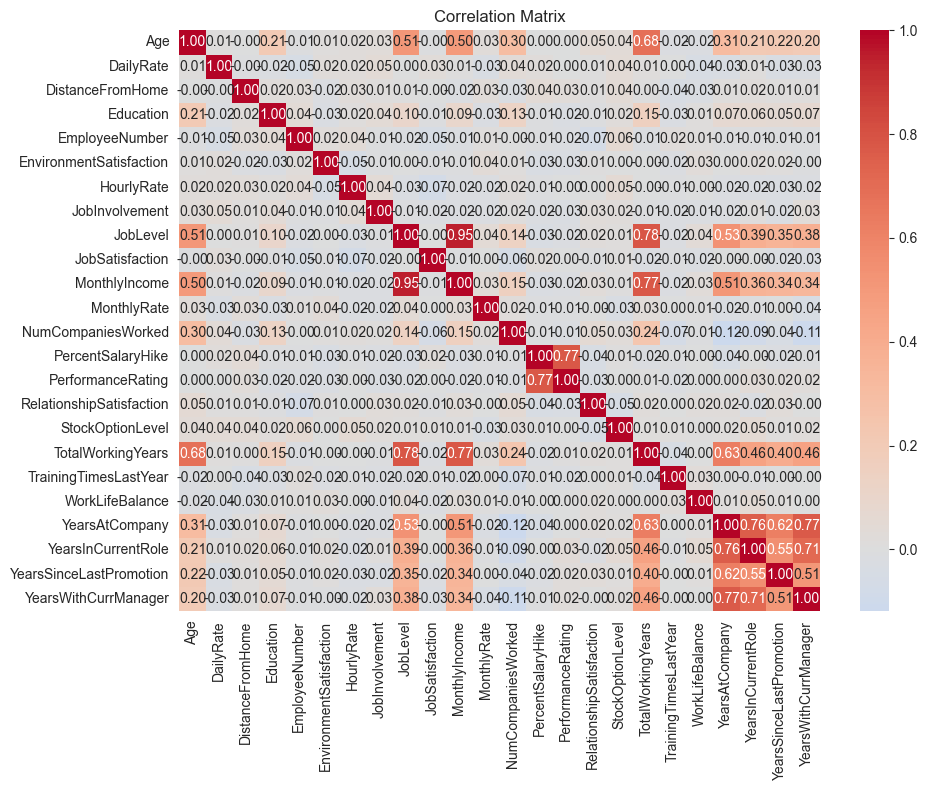

In [26]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
# 
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [27]:
# for EDA, attrition is temporarily encoded as 0/1 to allow for comparison with other numeric predictors
df['AttritionBinary'] = df['Attrition'].map({'No': 0, 'Yes': 1})

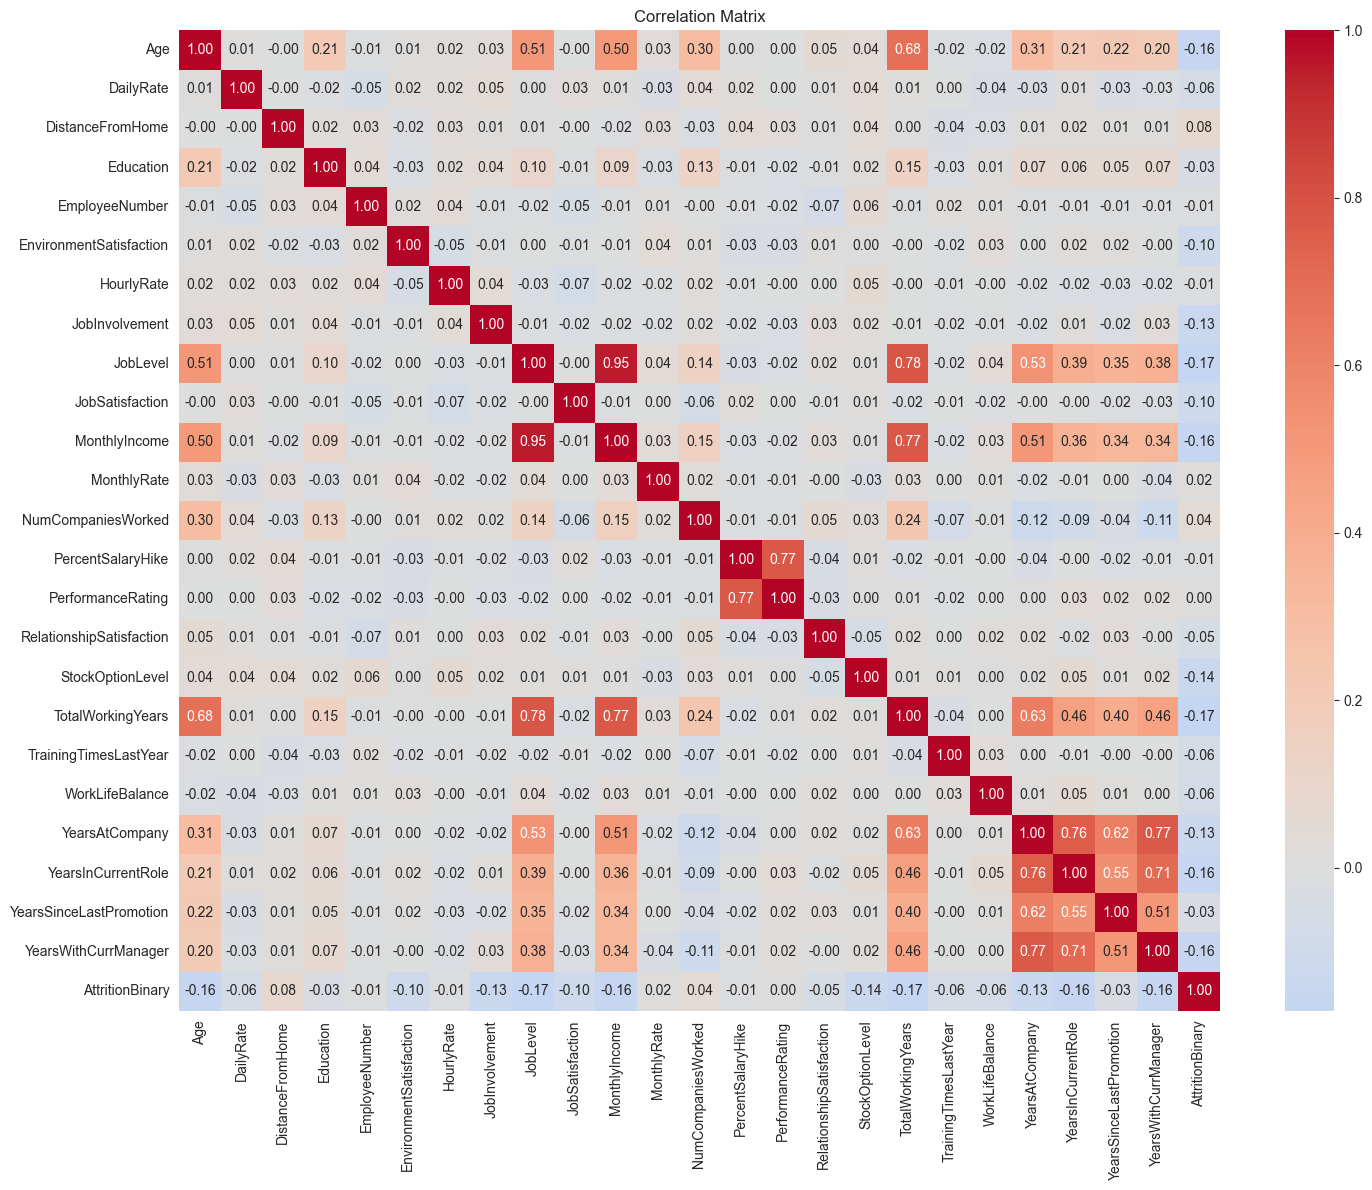

In [28]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
# 
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable "Attrition" which is a binary variable, is not balanced. The majority of employees were labeled as No, indicating they will not be leaving, while a smaller portion were labeled as Yes, meaning they will leave. As this is a moderately imbalanced classification problem, precision, recall, and the confusion matrix will be more insightful opposed to just accuracy alone. Further, weights can be used to account for the smaller class.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* From the original dataset, Attrition was provided as a categorical variable (yes / no), and as a result it was not included in the correlation matrix. For the EDA, I encoded the yes / no values into numerical values (1 and 0) to add into the matrix. From this, we see that the strongest associations are negative and modest in magnitude. Some of the most, relatively, correlated include predictors such as Age, JobLevel, MonthlyIncome, TotalWorkingYears, and YearsInCurrentRole. This subset suggests that more experienced / senior employees who are likely higher-paid are somewhat less likely to leave. This however is not a concrete conclusion, and requires further exploration to isolate impact of the predictors. We do also see some multicollineraity present amongst other predictors. Particularly, monthlyIncome and JobLevel are understandably correlated (higher-level roles pay more), as well as present corrrelation between many tenure-related indicators such as YearsSinceLastPromotion, YearsInCurrentRole, YearsAtCompany. The presence of this requires further caution when interpretting regression coefficients, due to potential interaction.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* I believe that the biggest data "quality issue" with this dataset is the afct that it is a fictitious dataset that was created by data scientists at IBM. The data being synthetic limits the generalizability of the findings to companies in the real-world or accross other industries. There do exists some numeric variables with outliers, however, these will be kept as such presence is likely even in real-world workforces and they are all possible values as well. There were 2 columns that had the constant values for all entries, and these were removed. 

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 1470** observations and **M = 31** features.

**Missing data:** 0% of cells are missing. The missingness pattern is not applicable as this dataset was artifically made by data scientists at IBM, so no imputation/handling is required. 

**Outliers:** I identified 7-8% outliers across 3 key numeric variables using Tukey Fence. I will handle them by keeping them, as the values are all possible (certain high-tenure high-income strong performers).

**Target variable:** The atrget variable, Attrition, is a binary variable, and is moderately imbalanced, the majority of observations being No, and a small portion being yes.

**Key finding from EDA:** There is potential multicollineraity, as some of the tenure and seniority related variables exhibit correlation amongst one another. Another key finding is that attrition seems to be influenced by a range of factors as opposed to being primarily influenced by a single predictor. 

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [29]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# # Define features and target
X = df.drop(columns=['Attrition'])
y = df['AttritionBinary']  # Replace with your target
# 
# # For classification: use stratify=y
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
# 
# # For regression: remove stratify
# # X_train, X_test, y_train, y_test = train_test_split(
# #     X, y, test_size=0.2, random_state=RANDOM_STATE
# # )
# 
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Number of features: {X_train.shape[1]}')

Train: 1176 samples
Test:  294 samples
Number of features: 32


### 3.2 Model 1: Baseline

In [30]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
#   Regression: LinearRegression or Ridge

from sklearn.linear_model import LogisticRegression  # or LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_model = df.drop(columns=['Attrition', 'EmployeeNumber'])

df_model['JobRole'] = pd.Categorical(
    df['JobRole'],
    categories=[
        'Sales Executive',  # <-- baseline (will be dropped)
        'Healthcare Representative',
        'Human Resources',
        'Laboratory Technician',
        'Manager',
        'Manufacturing Director',
        'Research Director',
        'Research Scientist',
        'Sales Representive'
    ],
    ordered=False
)

df_model['Department'] = pd.Categorical(
    df['Department'],
    categories=[
        'Research & Development',  # <-- baseline (will be dropped)
        'Sales',
        'Human Resources'
    ],
    ordered=False
)

df_model['EducationField'] = pd.Categorical(
    df['EducationField'],
    categories=[
        'Life Sciences',  # <-- baseline (will be dropped)
        'Medical',
        'Marketing',
        'Technical Degree',
        'Other',
        'Human Resources',
    ],
    ordered=False
)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    if str(df[col].dtype) == 'category':
        print(f"{col}: baseline = {df[col].cat.categories[0]}")
    else:
        categories = sorted(df[col].dropna().unique())
        dummy_cols = [c.replace(f"{col}_", "") for c in X.columns if c.startswith(f"{col}_")]
        dropped = [cat for cat in categories if cat not in dummy_cols]
        print(f"{col}: baseline = {dropped[0] if dropped else 'None found'}")

df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop(columns=['AttritionBinary'])
y = df_model['AttritionBinary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
model_1 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

model_1.fit(X_train_scaled, y_train)
 
y_pred_1 = model_1.predict(X_test_scaled)
# 
# # Classification metrics
print('Model 1: Logistic Regression')
print(classification_report(y_test, y_pred_1))

# 
# # Regression metrics (use these instead if regression)
# # print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
# # print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
# # print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Attrition: baseline = No
BusinessTravel: baseline = Non-Travel
Department: baseline = Human Resources
EducationField: baseline = Human Resources
Gender: baseline = Female
JobRole: baseline = Healthcare Representative
MaritalStatus: baseline = Divorced
OverTime: baseline = No
Model 1: Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.37      0.64      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.83      0.77      0.79       294



/var/folders/t_/75kz594n1mgf3j891lcdv84h0000gn/T/ipykernel_23193/822774385.py:15: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_model['JobRole'] = pd.Categorical(
/var/folders/t_/75kz594n1mgf3j891lcdv84h0000gn/T/ipykernel_23193/822774385.py:54: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


### 3.3 Model 2: Your Choice

In [31]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

from sklearn.ensemble import RandomForestClassifier  # or RandomForestRegressor
# 
model_2 = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", max_depth=5)
model_2.fit(X_train, y_train)
# 
y_pred_2 = model_2.predict(X_test)
# 
print('Model 2: Random Forest')
print(classification_report(y_test, y_pred_2))

Model 2: Random Forest
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       247
           1       0.45      0.51      0.48        47

    accuracy                           0.82       294
   macro avg       0.68      0.70      0.69       294
weighted avg       0.83      0.82      0.83       294



### 3.4 Cross-Validation Comparison

In [32]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
scoring = 'f1'
# 
cv_1 = cross_val_score(model_1, X_train_scaled, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
# 
print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
# 
# # Comparison table
comparison = pd.DataFrame({
     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
 })
comparison

Model 1 CV f1: 0.5141 +/- 0.0547
Model 2 CV f1: 0.4509 +/- 0.0375


,Model,CV f1 (mean),CV f1 (std)
0,Model 1 (Baseline),0.514051,0.054660
1,Model 2 (Your Choice),0.450891,0.037503


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

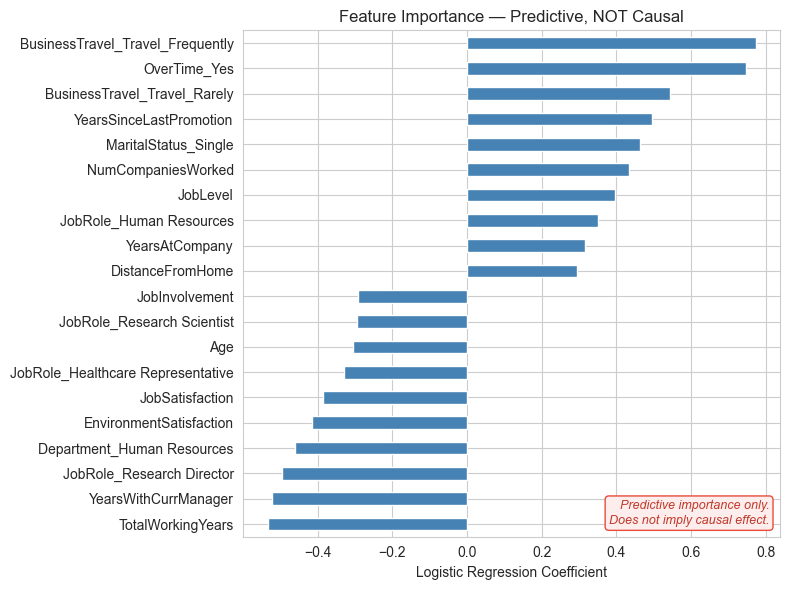

In [33]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
# 

coef_series = pd.Series(
    model_1.coef_[0],
    index=X_train.columns
).sort_values()

coef_plot = pd.concat([coef_series.head(10), coef_series.tail(10)])

fig, ax = plt.subplots(figsize=(8, 6))
coef_plot.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Feature Importance — Predictive, NOT Causal')
# 
ax.text(
    0.98, 0.02,
     'Predictive importance only.\nDoes not imply causal effect.',
     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
     style='italic', color='#c0392b',
     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
 )
# 
plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

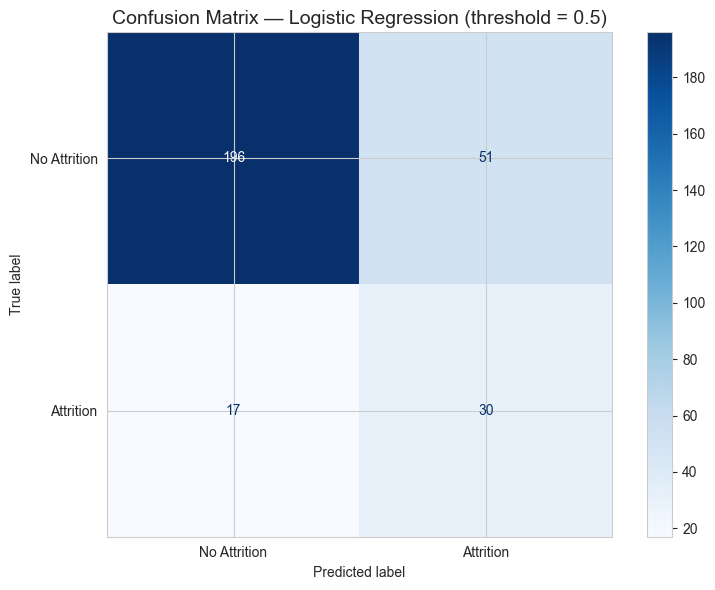

True Positives (attrition correctly predicted): 30
False Negatives (missed attrition cases):      17
False Positives (incorrect attrition flags):   51
True Negatives (correctly retained):           196


In [34]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_1)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Attrition', 'Attrition']
)
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (threshold = 0.5)', fontsize=14)

plt.tight_layout()
plt.show()

# Breakdown
tn, fp, fn, tp = cm.ravel()

print(f"True Positives (attrition correctly predicted): {tp}")
print(f"False Negatives (missed attrition cases):      {fn}")
print(f"False Positives (incorrect attrition flags):   {fp}")
print(f"True Negatives (correctly retained):           {tn}")

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:**  An HR team is looking to understand and try to predict employees who will leave the company, in an effort to to target support and retain talent. The key decision here is choosing which model will best support these efforts. 

**Complication:** Employees leaving is somewhat of an uncommon occurance. The dataset only shows ~16% of employees leaving, which creates an imbalanced classification problem. This induces uncertainity in model performance specifically identifying/predicting accurately which employees will leave. The analysis reveals that there are multiple features and indicators associated with attrition, and that there is not one dominating feature. It also uncovers that there exists some multicollinearity among the factors, and that there is a tradeoff between prioritizing minimizing false alarms and identifying more at risk employees. 

**Resolution:** The recommendation is to use the Logistic Regression model for this initiative. The model demonstrated a higher cross validated F1 score (0.51 vs 0.45) and higher recall for attrition (0.64 vs 0.51) comapred to the alternative RandomForest model. Further, the Logistic Regression model offers more interpretability, which makes it easier for HR teams to understand which factors increase risk of attrition, which makes this a moderately confident recommendation.

**Uncertainty Statement:** Based on the cross-validation results (F1 score = 0.514 +/- 0.0547), we estimate that this model can reliably predict a substantial proportion of at-risk employees. The primarily limitations are the class imbalance inherent with attrition being uncommon, and also the fact that this is a probablistic prediction rather than definitive. We recommend using this model to falg at-risk employees for further review, as while there may be more false-positives, it has fewer missed true-risk employees. The caveat should be that this should just be used as a predictive signal, and should be used in combination with further managerial assesment and intervention. 

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

In [17]:
import joblib

joblib.dump(model_1, "model.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> I trained my two models in the .ipynb starter file and needed to use it to create an interactive Streamlit dashboard with user input controls and a visualization.

**Request:** What exact prompt did you write?
> "Help me build a Streamlit app for my employee attrition model in the app.py file. I want the main visualization to be a bar graph split between the three business travel categories. The goal of the dynamic visualization is to have sliders and drop-down input controls to select a range of characteristics in the dataset. Then, using that combination, use the logistic regression model to predict attrition risk across the three different business travel categories (the last "parameter"). I want it so that there is a text label for each bar to show the determined probability, a green bar at the top of each bar, and then, based on the error uncertainty determined, red lines to mark those for each bar as well." 

**Iterate:** What did the AI return? What did you change or refine?
> The AI gave me a solid starting app.py that I tested locally and found to work. There were some issues with the visualization formatting, but I saw that it updated dynamically, which was a requirement. I did need to change the default values of some of the sliders, and include text that showed the highest risk group given the parameters, and their determined score. 

**Mechanism Check:** How did you verify the output was correct?
> I ran the provided draft code locally and validated that everything was populating and that slider adjustments were dynamically updating the visualization and displayed risk scores. 

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> The initial output was accepted as it satisfied the provided requirements. What i rejected was the provided default input values, and tuned them to better represent an "average" employee as the starting point. I also added some text to help better interpret the provided scores to help for interpretation by non-technical stakeholders. Further, I used judgment to base the output to be interpreted as a risk score as opposed to a true probability, as the class weighting used in the model biases the output and prevents it from being interpreted as a definitive probability.

---

### AI Interaction 2

**Prep:** My data set had a lot of categorical variables, and I needed to one-hot encode them to be able to be incorporated as predictors in my logistic regression model. 

**Request:** "When using pd.get_dummies for my one-hot encoding of categorical variables, how is the dropped variable determined. If I want to change that order, what do you recommend I should consider, and how can I adjust my code logic to manually adjust which category is dropped and used as the baseline?"

**Iterate:** The AI explained that the drop_first parameter of the pd.get_dummies function defaults to dropping the first category based on the category ordering by pandas (which can default to alphabetical as it did in my case). It also then confirmed that after this deletion, the remaining values would be interpreted relative to that baseline omitted category. I went back then to manually set the ordering to "choose" which category was used as the baseline for the categorical variables, so that I could make more generalizable and reasonable interpretations. For example, I looked through the data to find the most common job_role / department, and used those as the baseline for better interpretability.

**Mechanism Check:** After the one-hot encoding, I checked to ensure all columns were numerical and that each categorical variable was missing one category. I also included checks to see which categories were omitted / selected as each baseline to ensure they aligned with what I wanted to use as the interpretable baseline.

**Evaluate:** I used judgement to select the most common categories to use as the baseline as that helps with interpretability. I made sure to reject changing baselines solely for the sake of improving coefficients, and focused on objectively deciding on the most common categories, and accepted the disclaimer to not interpret as absolute effects, but rather as relative to the baseline.

---

### AI Interaction 3

**Prep:** In fitting my logistic regression model, I found that I was getting a convergence warning, that given the max number of iterations the model had not converged. The dataset included variables across different magnitude scales, such as the one-hot encoded variables between 0 and 1, and then variables like monthly income, which were in the 1000s. 

**Request:** "My logistic regression model is giving me a convergence warning. I have tried to increase the max_iterations parameter, but it is still unable to solve the warning. What does this mean about my model, and how can it be fixed for a dataset with both dummy variables and large continuous variables?"

**Iterate:** The AI informed that the convergence warning was likely a result of the model not settling on coefficient estimates within the iteration limit. It suggested either increasing max_iter or scaling the predictors. I started by iteratively testing marginally higher max_iter values, but did not find that to work. Thus, I went back and implemented a StandardScaler to standardize predictors for the model. 

**Mechanism Check:** I reran the model and ensured that the convergence warning disappeared. I also checked to make sure the recall, precision, and F1 results remained relatively consistent, to verify that the model was still picking up on the same relationships.

**Evaluate:** I accepted the scaling solution as the logistic regression was sensitive to the range in scales of numerical columns. Some one-hot encoded variables spanned either 0 or 1, while other variables were much larger in size. I made sure to keep the interpretations of the coefficients cautious, as the scaled coefficients do not reflect raw unit changes.